# California House Price Prediction

Predicting median house value for California districts using the
[`fetch_california_housing`](https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset)
dataset from scikit-learn.

**Workflow**
1. Load & explore the data
2. Feature engineering
3. Train/test split + preprocessing
4. Baseline model — Linear Regression
5. Stronger models — Ridge, Random Forest, XGBoost
6. Compare models
7. Save the best model for deployment


## 1. Imports

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import joblib

sns.set_style("whitegrid")
RANDOM_STATE = 42


## 2. Load & Explore the Data

`fetch_california_housing()` downloads the raw data on first use, so it needs internet
access. If that download is blocked (locked-down network, some campus/corporate proxies),
the cell below falls back to rebuilding the identical dataset from the original 1990 census
CSV, using the same transformation scikit-learn applies internally.

In [6]:
try:
    housing = fetch_california_housing()
    df = pd.DataFrame(housing.data, columns=housing.feature_names)
    df["Price"] = housing.target

except Exception as e:
    print("Direct download failed ({}), rebuilding from source census data...".format(type(e).__name__))

    raw = pd.read_csv(
        "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
    ).dropna(subset=["total_bedrooms"])

    df = pd.DataFrame({
        "MedInc": raw["median_income"],
        "HouseAge": raw["housing_median_age"],
        "AveRooms": raw["total_rooms"] / raw["households"],
        "AveBedrms": raw["total_bedrooms"] / raw["households"],
        "Population": raw["population"],
        "AveOccup": raw["population"] / raw["households"],
        "Latitude": raw["latitude"],
        "Longitude": raw["longitude"],
        "Price": raw["median_house_value"] / 100_000.0,
    }).reset_index(drop=True)

df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [7]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [8]:
df.describe()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [9]:
df.isnull().sum()


MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

In [10]:
corr = df.corr()["Price"].sort_values(ascending=False)
corr


Price         1.000000
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: Price, dtype: float64

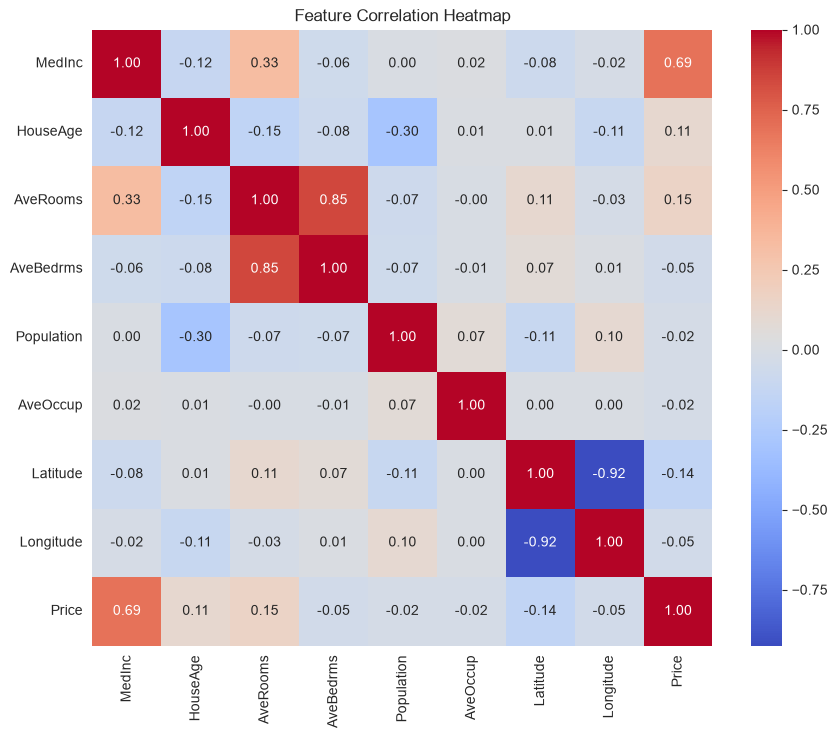

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


**Observation:** `MedInc` (median income) is by far the strongest predictor of price.
`Latitude`/`Longitude` matter too (location effects) but their relationship with price is
non-linear — which is a big part of why a plain linear model struggles on this dataset.

## 3. Feature Engineering

In [12]:
df["RoomsPerHousehold"] = df["AveRooms"] / df["AveOccup"]
df["BedroomsPerRoom"] = df["AveBedrms"] / df["AveRooms"]
df["PopulationPerHousehold"] = df["Population"] / df["AveOccup"]

df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price,RoomsPerHousehold,BedroomsPerRoom,PopulationPerHousehold
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,2.732919,0.146591,126.0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,2.956685,0.155797,1138.0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,2.957661,0.129516,177.0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,2.283154,0.184458,219.0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,2.879646,0.172096,259.0


## 4. Train/Test Split

In [13]:
X = df.drop("Price", axis=1)
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

X_train.shape, X_test.shape


((16512, 11), (4128, 11))

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


We'll keep a single results table (`results`) and a helper function so every model is
evaluated the exact same way — this is what was missing before and made it hard to compare
runs.

In [15]:
results = {}

def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}
    print(f"{name:<20} MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}")
    return mae, rmse, r2


## 5. Baseline — Linear Regression

Linear Regression is a good first model but it assumes a straight-line relationship between
each feature and price. `Latitude`/`Longitude` (location) and `MedInc` don't behave linearly
here, so this is expected to plateau around R2 ≈ 0.6 — that's the model, not a bug.

In [16]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

y_pred_lin = lin_reg.predict(X_test_scaled)
evaluate("Linear Regression", y_test, y_pred_lin)


Linear Regression    MAE=0.4874  RMSE=0.6738  R2=0.6535


(0.48743933112258514, 0.6738172773395145, 0.6535205948827303)

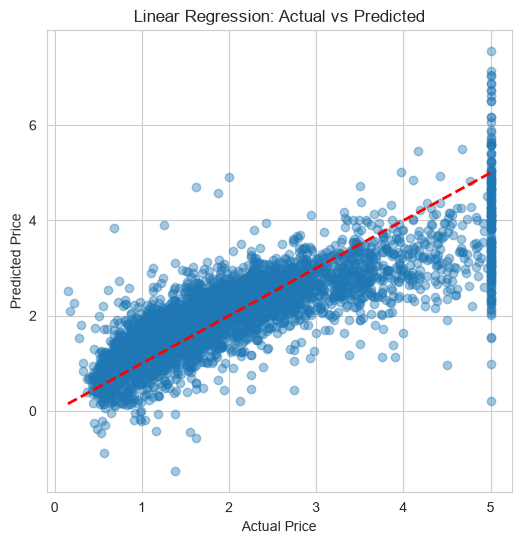

In [17]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_lin, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", linewidth=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()


## 6. Ridge Regression (regularized linear baseline)

In [18]:
ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)
evaluate("Ridge Regression", y_test, y_pred_ridge)


Ridge Regression     MAE=0.4874  RMSE=0.6738  R2=0.6535


(0.48743551550801906, 0.6738201776284442, 0.6535176121971285)

## 7. Decision Tree Regressor

A single tree can capture non-linear splits (e.g. location bands) that a linear model can't.

In [19]:
tree = DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)
evaluate("Decision Tree", y_test, y_pred_tree)


Decision Tree        MAE=0.4481  RMSE=0.6496  R2=0.6780


(0.448117395756179, 0.649610532574982, 0.6779678321505103)

## 8. Random Forest Regressor

In [20]:
rf = RandomForestRegressor(
    n_estimators=300, max_depth=None, n_jobs=-1, random_state=RANDOM_STATE
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
evaluate("Random Forest", y_test, y_pred_rf)


Random Forest        MAE=0.3276  RMSE=0.5031  R2=0.8068


(0.3276257384043931, 0.5031193720934454, 0.806831983923443)

## 9. XGBoost Regressor

In [21]:
xgb = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
evaluate("XGBoost", y_test, y_pred_xgb)


XGBoost              MAE=0.2924  RMSE=0.4449  R2=0.8489


(0.29237959040519573, 0.4449465596844483, 0.8489193494073947)

## 10. Model Comparison

In [22]:
results_df = pd.DataFrame(results).T.sort_values("R2", ascending=False)
results_df


,MAE,RMSE,R2
XGBoost,0.292380,0.444947,0.848919
Random Forest,0.327626,0.503119,0.806832
Decision Tree,0.448117,0.649611,0.677968
Linear Regression,0.487439,0.673817,0.653521
Ridge Regression,0.487436,0.673820,0.653518


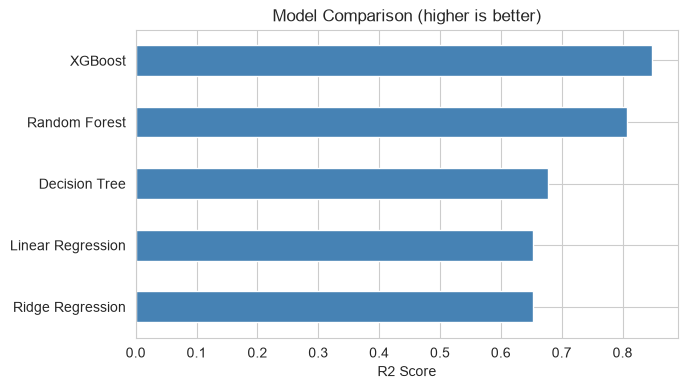

In [23]:
results_df["R2"].plot(kind="barh", figsize=(7, 4), color="steelblue")
plt.xlabel("R2 Score")
plt.title("Model Comparison (higher is better)")
plt.gca().invert_yaxis()
plt.show()


**Why Linear Regression underperforms here:** house price depends on features like
`Latitude`/`Longitude` in a highly non-linear, interaction-heavy way (price doesn't rise or
fall steadily with coordinates — it depends on *where* specifically). Tree-based models
(Random Forest, XGBoost) split the feature space instead of fitting one global line, so they
capture that structure. This isn't something to "fix" in Linear Regression — it's the reason
we compare it against other model families and deploy whichever wins.

## 11. Feature Importance (best tree-based model)

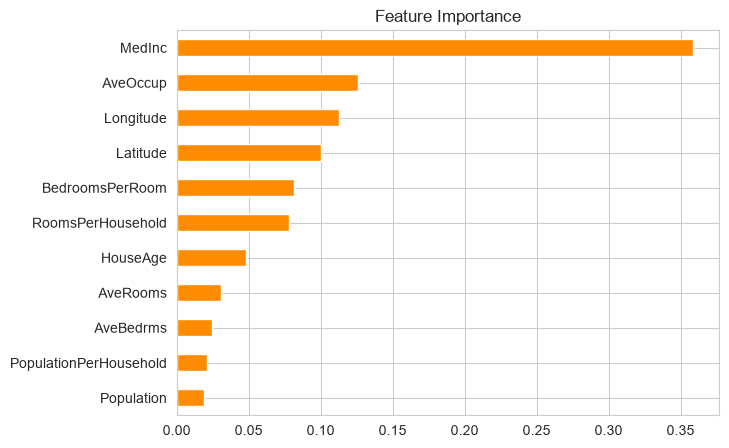

In [24]:
best_tree_model = xgb  # swap for `rf` if Random Forest wins on your run

importances = pd.Series(best_tree_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind="barh", figsize=(7, 5), color="darkorange")
plt.title("Feature Importance")
plt.show()


## 12. Save the Best Model

Saves the winning model (by R2) plus the scaler, so the web app can load both and reproduce
preprocessing exactly.

In [25]:
best_name = results_df.index[0]
model_lookup = {
    "Linear Regression": lin_reg,
    "Ridge Regression": ridge,
    "Decision Tree": tree,
    "Random Forest": rf,
    "XGBoost": xgb,
}
best_model = model_lookup[best_name]
print("Best model:", best_name)

joblib.dump(best_model, "house_price_model.joblib")
joblib.dump(scaler, "scaler.joblib")
joblib.dump(list(X.columns), "feature_names.joblib")


Best model: XGBoost


['feature_names.joblib']

## 13. Sanity-check a Single Prediction

In [26]:
sample = X_test.iloc[[0]]
scaled_needed = best_name in ("Linear Regression", "Ridge Regression")

pred = best_model.predict(scaler.transform(sample) if scaled_needed else sample)[0]

print("Predicted:", round(pred, 3))
print("Actual   :", round(y_test.iloc[0], 3))


Predicted: 0.507
Actual   : 0.477


In [27]:
y_pred_all = best_model.predict(X_test)

pd.DataFrame({"Actual": y_test.values, "Predicted": y_pred_all})

,Actual,Predicted
0,0.47700,0.507035
1,0.45800,0.904589
2,5.00001,4.995609
3,2.18600,2.373654
4,2.78000,2.454914
...,...,...
4123,2.63300,2.406603
4124,2.66800,1.949645
4125,5.00001,4.924225
4126,0.72300,0.687464


In [28]:
from sklearn.model_selection import GridSearchCV, cross_val_score

param_grid = {
    "n_estimators": [300, 500, 700],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}

from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid,
    n_iter=30,        # only 30 combos instead of 243
    scoring="r2",
    cv=5,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
)
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.03, 0.05, ...], 'max_depth': [4, 6, ...], 'n_estimators': [300, 500, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function which

In [29]:
XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist")

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [30]:
print("Best params:", random_search.best_params_)
print("Best CV R2 :", random_search.best_score_)

best_xgb = random_search.best_estimator_
y_pred_tuned = best_xgb.predict(X_test)
evaluate("XGBoost (tuned)", y_test, y_pred_tuned)

Best params: {'subsample': 0.7, 'n_estimators': 700, 'max_depth': 8, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
Best CV R2 : 0.8489551877434037
XGBoost (tuned)      MAE=0.2856  RMSE=0.4399  R2=0.8523


(0.2856332015457772, 0.4399187081213384, 0.8523144507030614)

In [31]:
cv_scores = cross_val_score(best_xgb, X, y, cv=5, scoring="r2")
print("CV R2 scores:", cv_scores)
print("CV R2 mean/std:", cv_scores.mean(), cv_scores.std())

CV R2 scores: [0.60344278 0.72601767 0.74973834 0.69389276 0.60008288]
CV R2 mean/std: 0.6746348858394684 0.062093319443991345


In [32]:
from sklearn.model_selection import KFold

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_xgb, X, y, cv=cv, scoring="r2")

print("CV R2 scores:", cv_scores)
print("CV R2 mean/std:", cv_scores.mean(), cv_scores.std())

CV R2 scores: [0.85175913 0.85712585 0.84383186 0.86687823 0.85225305]
CV R2 mean/std: 0.8543696242038988 0.007568367930453303


In [33]:
y_pred_final = best_xgb.predict(X_test)

pd.DataFrame({"Actual": y_test.values, "Predicted": y_pred_final})

,Actual,Predicted
0,0.47700,0.506031
1,0.45800,0.869233
2,5.00001,4.902334
3,2.18600,2.364842
4,2.78000,2.409932
...,...,...
4123,2.63300,2.469241
4124,2.66800,2.116704
4125,5.00001,4.845693
4126,0.72300,0.643429
